# Notebook 19 (V4_3) — Notebook 15 AHP plots at $T_{solved}=110$

This notebook fixes the calibration at Notebook 15's selected `pathwise_hi_exp_pi075` parameters and reproduces its four figure groups on a hard-valid 110-period solution. The first 15 periods remain the AHP evidence window; periods 16–110 are shown as the unscored tail.

The calibration search is not rerun. Instead, the selected equilibrium is extended using the successful numerical strategy documented by Notebook 17.

## Why this solves at 110

Notebook 15 cold-solves finalists at `T=30` with a scratch buffer. Notebook 17 demonstrates that the same branch remains hard-valid beyond 110 when it instead uses:

- `n_buffer = 0`, so the requested and reported solved horizons coincide;
- the decay-consistent local log-linear artificial successor for period `T+1`;
- warm continuation through `30, 45, 60, 70, 80, 90, 100, 105, 110`; and
- an escalating branch-iteration schedule of `60, 200` if a stage needs a retry.

The AHP accounting below also replaces Notebook 15's incidental call to `nfa_decomposition` with the direct equilibrium identity `NFA = A - Q_US`. This avoids invoking an unrelated terminal fundamental-value recursion at the long horizon.

In [1]:
function nb19_notebook_project_dir(start_dir=pwd())
    dir = abspath(start_dir)
    while true
        for candidate in (dir, joinpath(dir, "Codes"))
            script = joinpath(candidate, "Two_country_production",
                              "19_v9_ahp_pattern_T110_replication.jl")
            isfile(script) && return candidate
        end
        parent = dirname(dir)
        parent == dir && error("Could not locate the Notebook 19 script")
        dir = parent
    end
end

nb19_project_dir = nb19_notebook_project_dir()
include(joinpath(nb19_project_dir, "Two_country_production",
                 "19_v9_ahp_pattern_T110_replication.jl"))

  Activating 

Project directory:             /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes

project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`



Output directory:              /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_pattern_T110_replication
Requested solved horizon:      110
Scratch buffer:                0
Warm-continuation horizons:    

[30, 45, 60, 70, 80, 90, 100, 105, 110]
Branch-iteration schedule:     [60, 200]
Solving T=30, buffer=0, branch_iters=60, warm_T=


...

Solving T=70, buffer=0, branch_iters=60, warm_T=60
Solving T=80, buffer=0, branch_iters=60, warm_T=70


Solving T=90, buffer=0, branch_iters=60, warm_T=80
Solving T=100, buffer=0, branch_iters=60, warm_T=90


Solving T=105, buffer=0, branch_iters=60, warm_T=100
Solving T=110, buffer=0, branch_iters=60, warm_T=105



NOTEBOOK 19 — NOTEBOOK 15 AHP FIGURES ON THE T=110 CONTINUATION
Final max u residual:             3.557e-07
Final max BGP residual:           9.985e-10
Max first-window replication err: 6.431e-10
t=15 rebased NFA:                 -0.037937
t=15 net VA / cumulative CA:      -0.048656 / +0.010719
|VA| / |CA|:                      4.539


State-specific nu_b_eff range:    [0.172235, 1.660653]
Maximum common-growth log gap:    4.088e-09
Hard-valid T=110 solution:         true
Artifacts written to:             /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_pattern_T110_replication


## Notebook 15 figure replication on the full solution

The original styling is retained: the first-window series are opaque and the post-15 tail is muted.

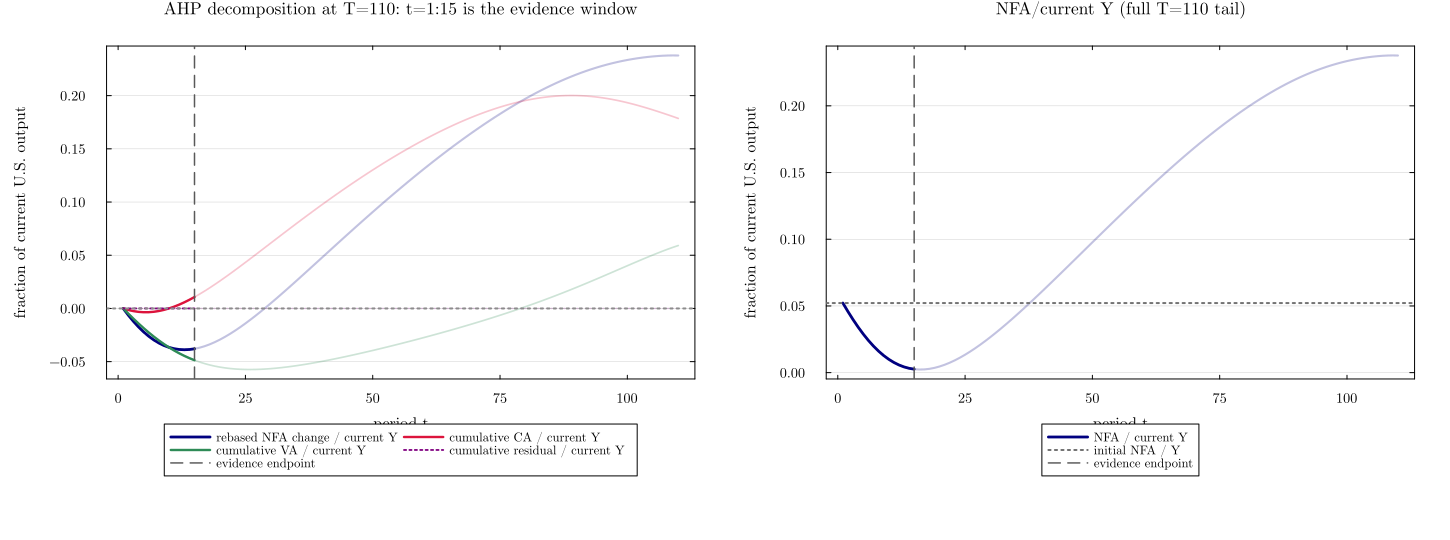

In [2]:
fig_ahp_two_panel

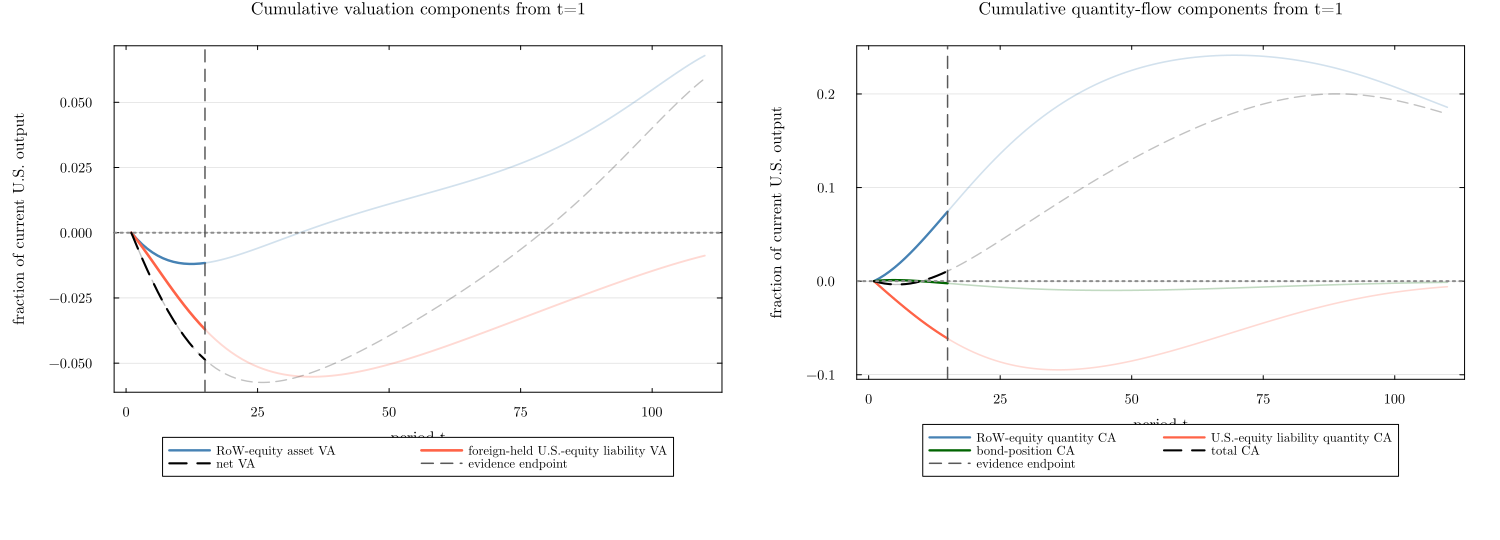

In [3]:
fig_subcomponents

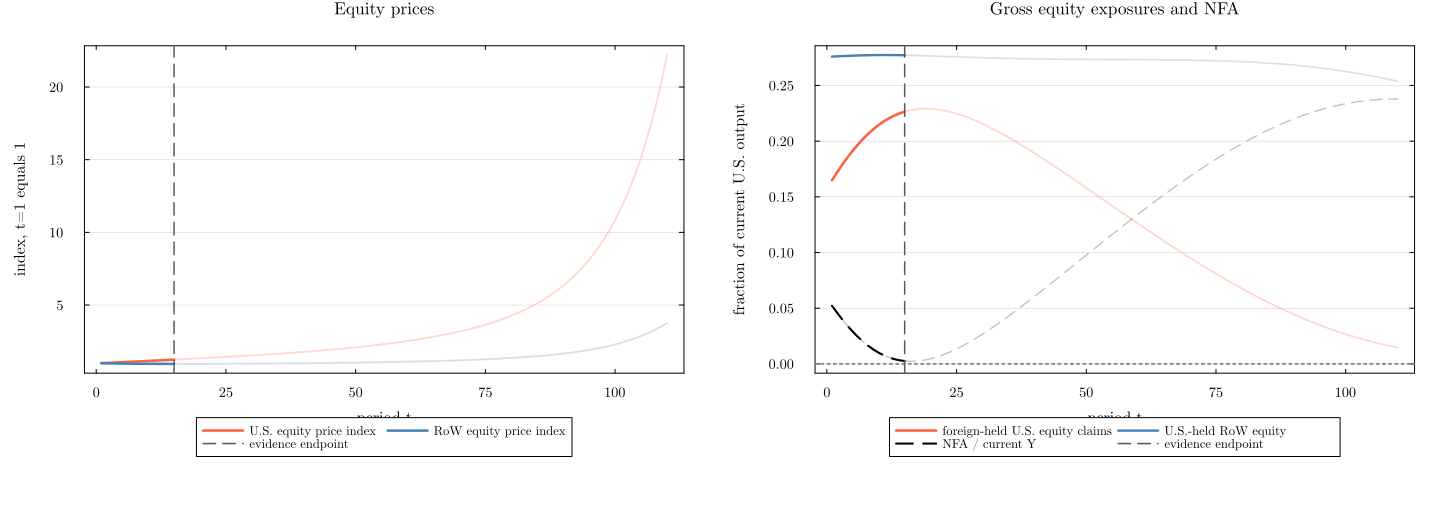

In [4]:
fig_prices_exposures

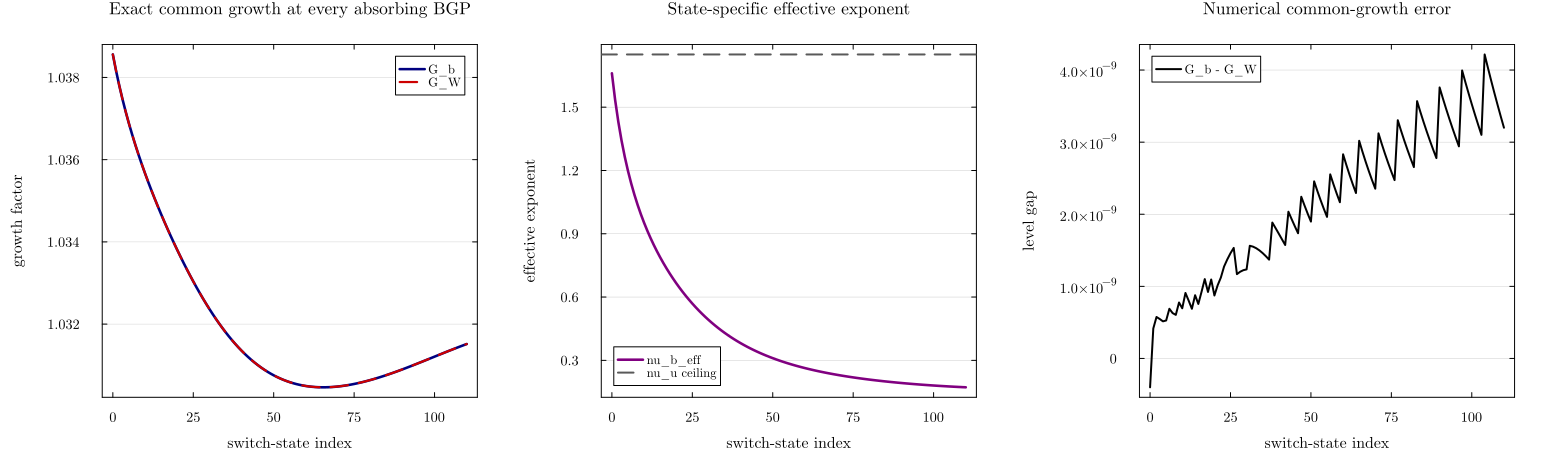

In [5]:
fig_common_growth

## Certification summary

The assertions in the solve cell require both the Notebook 15/17 hard-validity gates and a first-window match to Notebook 15 within `2e-5`.

In [6]:
@printf("T_solved:                         %d\n", T_solved)
@printf("Hard-valid solution:              %s\n", best_validity.valid)
@printf("Maximum u residual:               %.3e\n", best_result.max_u_residual)
@printf("Maximum BGP residual:             %.3e\n", best_result.max_bgp_residual)
@printf("First-window replication error:   %.3e\n", nb19_max_first_window_error)
@printf("t=15 rebased NFA / current Y:     %+.6f\n", best_metrics.target_rebased_nfa)
@printf("t=15 net VA / cumulative CA:      %+.6f / %+.6f\n",
        best_metrics.target_net_va, best_metrics.target_ca)
@printf("Maximum common-growth log gap:    %.3e\n", best_common_summary.max_log_gap)
println("Artifacts:                         ", NB19_OUTDIR)

T_solved:                         110
Hard-valid solution:              true
Maximum u residual:               3.557e-07
Maximum BGP residual:             9.985e-10
First-window replication error:   6.431e-10
t=15 rebased NFA / current Y:     -0.037937
t=15 net VA / cumulative CA:      -0.048656 / +0.010719
Maximum common-growth log gap:    4.088e-09
Artifacts:                         /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_pattern_T110_replication


## Parameter sweeps for bubble bounds and leakage contributions

This section translates the $\pi$ and $\gamma$ sweeps in Section 8 of the single-country HKT notebook to the AHP-calibrated two-country model. All unswept primitives remain at their AHP values. The final horizon is `T_max = 105`, with `n_buffer = 0`.

For every parameter value, the equilibrium is extended by warm continuation through `30, 45, 60, 70, 80, 90, 100, 103, 104, 105`. The theoretical bubble-share interval uses cutoff $K=103$ and checks its finite prefix against the separate `T=104` solution. The five displayed objects are: the theoretical upper bound, the theoretical lower bound, $a_t$, $d_t^u/q_t^u$, and the weighted switch contribution $(1-\pi)L_t/\pi$.

In [7]:
include(joinpath(nb19_project_dir, "Two_country_production",
                 "19_v9_ahp_pattern_T110_sweeps_T105.jl"))


Two-country AHP-calibration parameter sweeps
Final sweep horizon T_max:      105
Reference horizon:              104
Bound cutoff K:                 103
Endpoint guard:                 2
π grid:                         

[0.7, 0.75, 0.8, 0.9, 0.95, 0.97, 0.99, 0.995]
γ grid:                         [0.05, 0.25, 0.5, 0.75, 0.9]
pi           π = 0.7               T= 30 iter= 60 warm=
pi           π = 0.7               T= 45 iter= 60 warm=30


pi           π = 0.7               T= 60 iter= 60 warm=45
pi           π = 0.7               T= 70 iter= 60 warm=60


pi           π = 0.7               T= 80 iter= 60 warm=70
pi           π = 0.7               T= 90 iter= 60 warm=80


pi           π = 0.7               T=100 iter= 60 warm=90
pi           π = 0.7               T=103 iter= 60 warm=100


...

gamma        γ = 0.9               T=100 iter= 60 warm=90
gamma        γ = 0.9               T=103 iter= 60 warm=100


gamma        γ = 0.9               T=104 iter= 60 warm=103
gamma        γ = 0.9               T=105 iter= 60 warm=104



Sweep certification summary


sweep        case                max u res  prefix gap prefix ok   finite env bound status
pi           π = 0.7             2.594e-07   2.409e-05      true         true diagnostic_only_hkt_gate_failed


pi           π = 0.75 (AHP)      2.900e-07   3.039e-05      true         true diagnostic_only_hkt_gate_failed
pi           π = 0.8             3.425e-07   3.150e-05      true         true diagnostic_only_hkt_gate_failed
pi           π = 0.9             4.768e-07   2.511e-05      true         true diagnostic_only_hkt_gate_failed
pi           π = 0.95            5.273e-07   2.170e-05      true         true diagnostic_only_hkt_gate_failed
pi           π = 0.97            5.200e-07   2.260e-05      true         true diagnostic_only_hkt_gate_failed
pi           π = 0.99                                      false        false unavailable at T=105
pi           π = 0.995                                     false        false unavailable at T=105
gamma        γ = 0.05            3.591e-07   3.449e-05      true         true diagnostic_only_hkt_gate_failed
gamma        γ = 0.25 (AHP)      2.900e-07   3.039e-05      true         true diagnostic_only_hkt_gate_failed
gamma        γ = 0.5            

### Sweep over persistence $\pi$

The single-country grid is retained, and $\pi=0.75$ is added and marked as the AHP baseline.

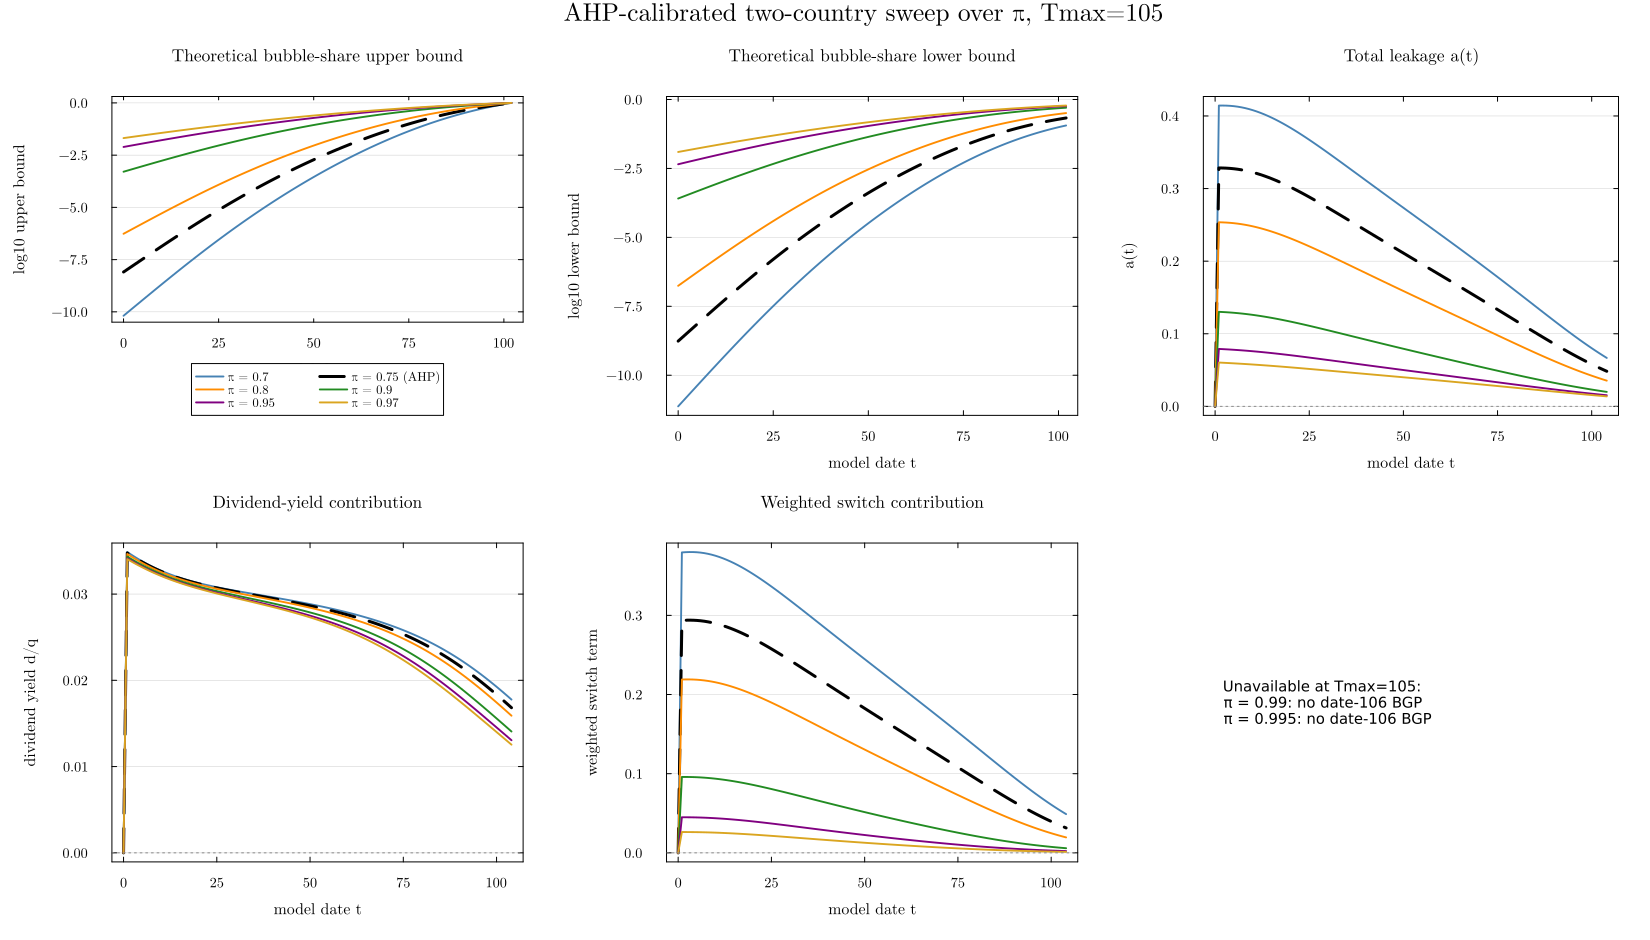

In [8]:
pi_sweep_five_quantity_fig

### Sweep over risk aversion $\gamma$

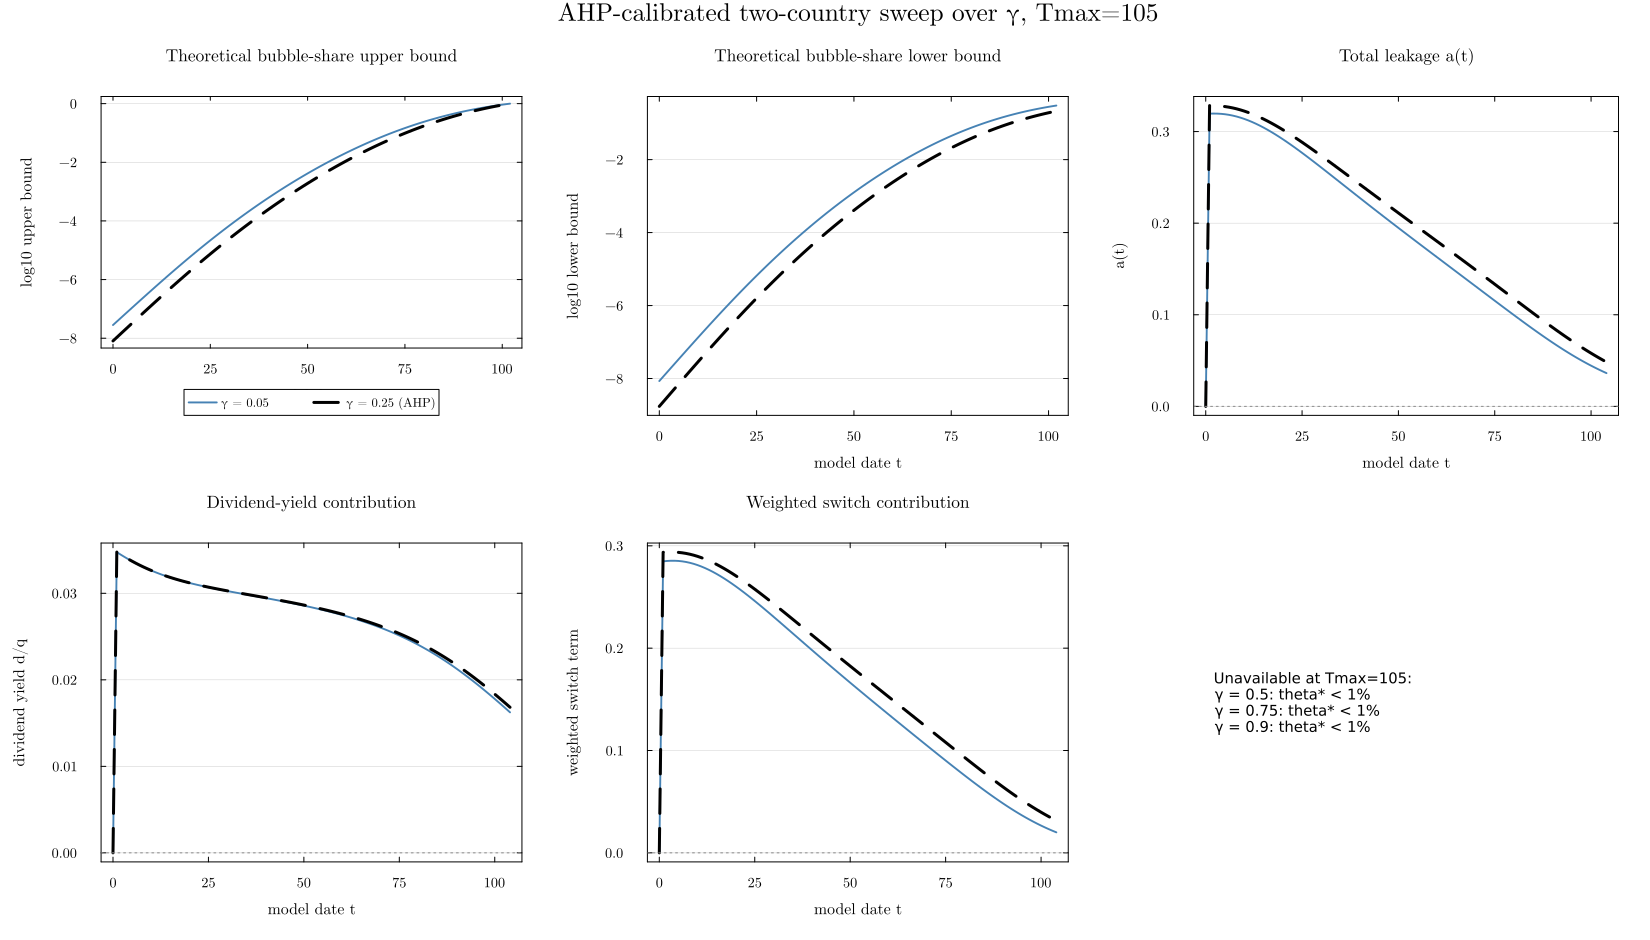

In [9]:
gamma_sweep_five_quantity_fig

### Econometric and theoretical qualification

These are comparative-static exercises around the AHP calibration, not fresh AHP calibrations at every grid point. Moreover, at `T_max=105` a plotted lower bound is conditional on the finite-tail envelope diagnostics and on extrapolating the observed tail bounds beyond the solved horizon. The CSV summary reports the HKT entry gate separately; the notebook does not label a conditional diagnostic as a certified infinite-horizon bound.

The unavailable grid points are substantive diagnostics rather than silently dropped observations. At $\pi=0.99,0.995$, the regular absorbing-BGP continuation fails at the required date-106 successor. At $\gamma=0.5,0.75,0.9$, the equilibrium is residual-safe but the foreign U.S.-equity weight falls below the maintained one-percent interiority threshold, so Notebook 17's hard-validity gate rejects the path.

In [10]:
all_sweep_cases = vcat(pi_sweep_cases, gamma_sweep_cases)
solved_sweep_cases = vcat(pi_sweep_results, gamma_sweep_results)
unavailable_sweep_cases = filter(c -> c.status != :ok, all_sweep_cases)
unavailable_labels = join([c.label for c in unavailable_sweep_cases], ", ")
println("Requested sweep cases:             ", length(all_sweep_cases))
println("Hard-valid T_max=105 cases:        ", length(solved_sweep_cases))
println("Unavailable T_max=105 cases:       ",
        isempty(unavailable_labels) ? "none" : unavailable_labels)
println("Finite-envelope diagnostics passing: ",
        count(r.bound.summary.finite_envelope_diagnostics_pass
              for r in solved_sweep_cases),
        " / ", length(solved_sweep_cases))
println("HKT entry gates passing at T_max=105: ",
        count(r.bound.summary.hkt_entry_gate
              for r in solved_sweep_cases),
        " / ", length(solved_sweep_cases))
println("Detailed qualification: ",
        joinpath(NB19_OUTDIR, "sweep_case_summary.csv"))

Requested sweep cases:             13
Hard-valid T_max=105 cases:        8
Unavailable T_max=105 cases:       π = 0.99, π = 0.995, γ = 0.5, γ = 0.75, γ = 0.9
Finite-envelope diagnostics passing: 8 / 8
HKT entry gates passing at T_max=105: 0

 / 8
Detailed qualification: /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/outputs_v43/ahp_pattern_T110_replication/sweep_case_summary.csv
